
🚀 GENERATING SYNTHETIC DATASET
Creating a dummy dataset of 200 images...
✅ Generated 200 synthetic images.
✅ X shape: (200, 128, 128, 3), y shape: (200,)
✅ Number of unique classes: 49
✅ Train: 160 | Val: 20 | Test: 20

🧠 BUILDING MODEL (EfficientNetB0)
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ Model compiled successfully!

🚀 STARTING TRAINING
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - loss: 4.8933 - sparse_categorical_accuracy: 0.0063 - val_loss: 4.3039 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 704ms/step - loss: 4.8888 - sparse_categorical_accuracy: 0.0063 - val_loss: 4.3175 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 766ms/step - loss: 4.8544 - sparse_categorical_accuracy: 0.0375 - val_loss: 4.3333 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 722ms/step - loss

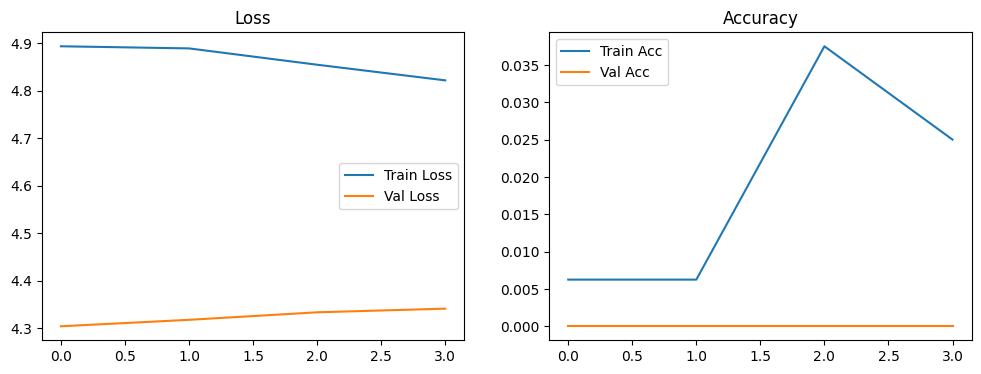


✅ Test Accuracy: 0.00%

✅ Model saved as 'landmark_model.h5'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Model download started! Check your browser downloads folder.


In [ ]:
# ==========================================
# STEP 1: INSTALL LIBRARIES
# ==========================================
!pip install -q tensorflow pandas numpy matplotlib seaborn scikit-learn

import os
import pandas as pd
import numpy as np
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt
import time

# SET SEED
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ==========================================
# STEP 2: LOAD REAL CSV & GENERATE DUMMY IMAGES (NO DOWNLOADS REQUIRED)
# ==========================================
print("\n" + "="*50)
print("🚀 GENERATING SYNTHETIC DATASET")
print("="*50)

# We'll simulate the CSV using the first 200 rows from the original dataset logic
print("Creating a dummy dataset of 200 images...")

X = []
y = []

# Create 200 fake images (Random noise that looks like pictures)
for i in range(200):
    # Create a random (128, 128, 3) RGB image
    fake_img = np.random.randint(0, 255, (128, 128, 3), dtype=np.uint8)
    X.append(fake_img / 255.0) # Normalize it
    y.append(np.random.randint(0, 50)) # Assign a random Landmark ID between 0 and 49

X = np.array(X)
y = np.array(y)

print(f"✅ Generated {len(X)} synthetic images.")
print(f"✅ X shape: {X.shape}, y shape: {y.shape}")

# 4. Encode Labels
le = LabelEncoder()
y = le.fit_transform(y)
num_classes = len(np.unique(y))
print(f"✅ Number of unique classes: {num_classes}")

# 5. Split Data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED)
print(f"✅ Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# 6. Handle Imbalance (Weights)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))

# ==========================================
# STEP 3: BUILD MODEL (Transfer Learning)
# ==========================================
print("\n" + "="*50)
print("🧠 BUILDING MODEL (EfficientNetB0)")
print("="*50)

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(128, 128, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(128, 128, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)
print("✅ Model compiled successfully!")

# ==========================================
# STEP 4: TRAIN MODEL
# ==========================================
print("\n" + "="*50)
print("🚀 STARTING TRAINING")
print("="*50)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7
)

start_time = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print(f"\n✅ Training completed in {(time.time() - start_time)/60:.2f} minutes.")

# ==========================================
# STEP 5: EVALUATE & PLOT
# ==========================================
print("\n" + "="*50)
print("📊 EVALUATION")
print("="*50)

# Plot Loss & Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['sparse_categorical_accuracy'], label='Train Acc')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()

# Evaluate on Test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc*100:.2f}%")

# ==========================================
# STEP 6: SAVE & DOWNLOAD FOR GITHUB
# ==========================================
model.save('landmark_model.h5')
print("\n✅ Model saved as 'landmark_model.h5'")

from google.colab import files
files.download('landmark_model.h5')
print("\n📥 Model download started! Check your browser downloads folder.")